In [ ]:
# choose 3 flightlines, maximally distant in space and time

# but I can only select from the 4 that have been re-uploaded lol

In [1]:
import os
from glob import glob
import numpy as np
from spectral.io import envi
from spectral.io.envi import read_envi_header
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box
import geopandas as gpd

# %matplotlib widget

In [3]:
home = '/store/carroll/col/data/2018/'
raw = home + 'raw/rmbl/'

igms = [x for x in glob(raw+'*/*_rdn_ort_igm.hdr', recursive=True)]
flightlines = [x.split('/')[-1].removesuffix('_rdn_ort_igm.hdr') for x in igms]

In [4]:
# set up df with mean coordinates and day for each flightline

df = pd.DataFrame(flightlines, columns=['flight'])
df['mean_northing'] = pd.NA
df['mean_easting'] = pd.NA
df['day'] = [x.split('_')[1] for x in df['flight']]

for i in range(len(igms)):
    fp = igms[i]
    flight = flightlines[i]

    igm = envi.open(fp).load().copy()
    mean_easting = np.nanmean(igm[...,0])
    mean_northing = np.nanmean(igm[...,1])
    df.loc[df.flight==flight, 'mean_northing'] = mean_northing
    df.loc[df.flight==flight, 'mean_easting'] = mean_easting

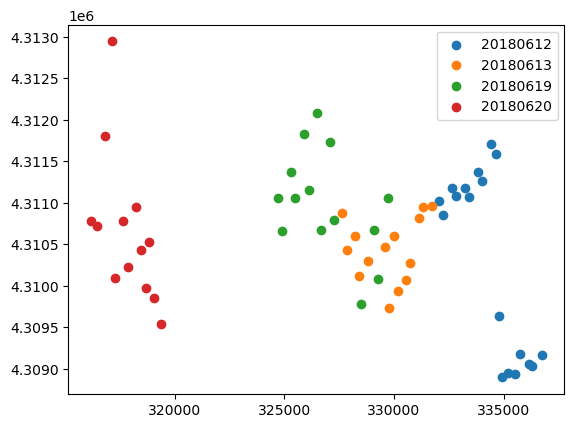

In [5]:
# viz
fig = plt.figure()
for day in df.day.unique():
    df_ = df[df.day==day]
    plt.scatter(df_.mean_easting, df_.mean_northing, label=day)
plt.legend()
plt.show()

In [6]:
# based on above, i'll use one flight from the 20th, 19th, 12th (not 13th)
df = df[df['day'] != '20180613']
print(len(df))

# and remove upper clump from 6/12
df = df[~((df['day'] == '20180612') & (df['mean_northing'] > 4310000))]
len(df)

45


35

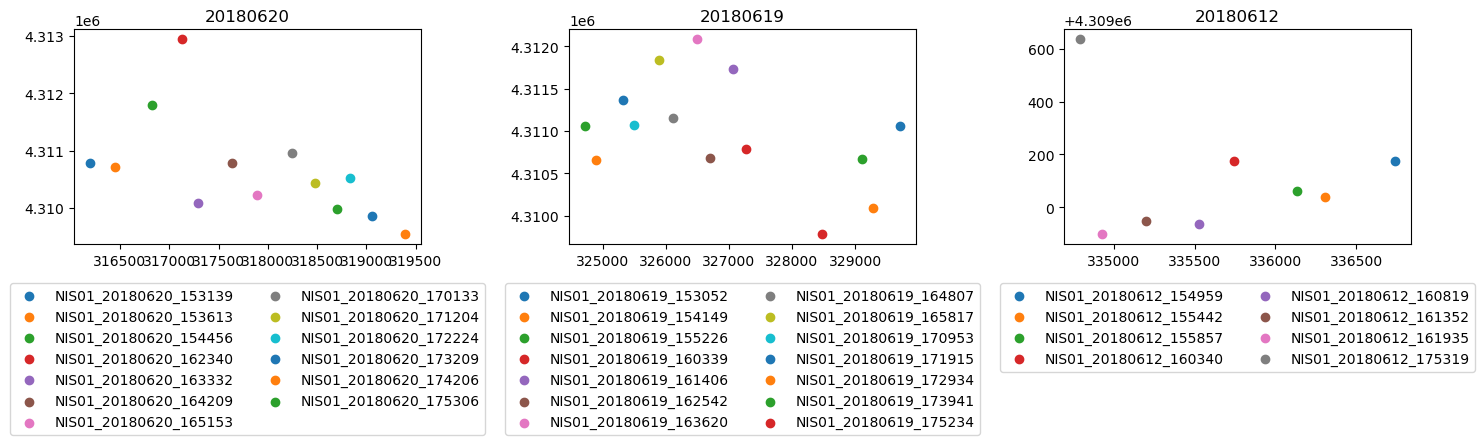

In [7]:
# viz each fligthline to manually select

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))

days = ['20180620', '20180619', '20180612']

for i in range(len(days)):
    day = days[i]
    df_ = df[df.day==day]
    for f in df_.flight.unique():
        df__ = df_[df_.flight==f]
        axs[i].scatter(df__.mean_easting, df__.mean_northing, label=f)
    axs[i].set_title(day)
    axs[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.5)  # give extra space at bottom
plt.show()

In [12]:
# manual selection
use = ['NIS01_20180620_162340', 'NIS01_20180619_162542', 'NIS01_20180612_155442']

In [11]:
# check their sizes
fps = [x for x in igms if any(x_ in x for x_ in use)]

for fp in fps:
    print(fp)
    hdr = read_envi_header(fp)
    print(hdr['samples'], hdr['lines'])

/store/carroll/col/data/2018/raw/rmbl/2018061214/NIS01_20180612_155442_rdn_ort_igm.hdr
598 7070
/store/carroll/col/data/2018/raw/rmbl/2018061914/NIS01_20180619_162542_rdn_ort_igm.hdr
598 42320
/store/carroll/col/data/2018/raw/rmbl/2018062013/NIS01_20180620_162340_rdn_ort_igm.hdr
598 15652


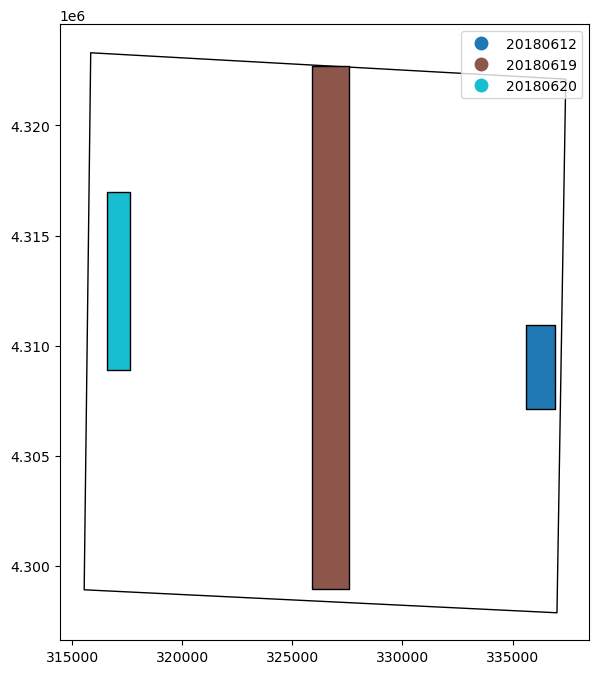

In [15]:
# final viz
campaign_bbox = gpd.read_file('/store/carroll/col/data/2018/raw/BoundingBox.kmz').to_crs(32613)

flightlines = glob('/store/carroll/col/data/2018/raw/rmbl/*/*_igm.hdr') # use the ort loc data
flightlines = [x for x in flightlines if any(s in x for s in use)]

boxes = []
for fp in flightlines:
    flight = fp.split('/')[-1].removesuffix('_rdn_ort_igm.hdr') # to update with cluster file paths
    date = flight.split('_')[1]
    
    # get loc bounds
    loc = envi.open(fp).open_memmap()
    max_x = np.nanmax(loc[...,0])
    min_x = np.nanmin(loc[...,0])
    max_y = np.nanmax(loc[...,1])
    min_y = np.nanmin(loc[...,1])
    boxes.append({"flight": flight, "date": date, "geometry": box(min_x, min_y, max_x, max_y)})
gdf = gpd.GeoDataFrame(boxes)

fig, ax = plt.subplots(figsize=(8,8))
campaign_bbox.plot(ax=ax, label='campaign', edgecolor='k', color='white')
gdf.plot(ax=ax, column="date", categorical=True, edgecolor="k", linewidth=1, legend=True)
plt.show()